In [1311]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc

In [1312]:
import pandas as pd
filex = '../analytical_examples/homoflat/Ux_file_an'
filez = '../analytical_examples/homoflat/Uz_file_an'
filesource = '../analytical_examples/homoflat/source'
uz = pd.read_csv(filez, header=None, sep=r"\s+").to_numpy().ravel()
vz_analytic=-uz[~np.isnan(uz)].reshape(-1, 21)
ux = pd.read_csv(filex, header=None, sep=r"\s+").to_numpy().ravel()
vx_analytic=ux[~np.isnan(ux)].reshape(-1, 21)
source = pd.read_csv(filesource, header=None, sep=r"\s+").to_numpy().ravel().reshape(-1, 2)
time_analytic = vz_analytic[:, 0]*-1
source_analytic = source[:,1]

In [1313]:
# Rotate componets
theta = -45.0  # degrees
theta_rad = np.deg2rad(theta)
vx_rotated = vx_analytic * np.cos(theta_rad) + vz_analytic * np.sin(theta_rad)
vz_rotated = -vx_analytic * np.sin(theta_rad) + vz_analytic * np.cos(theta_rad)
vx_analytic = vx_rotated
vz_analytic = vz_rotated

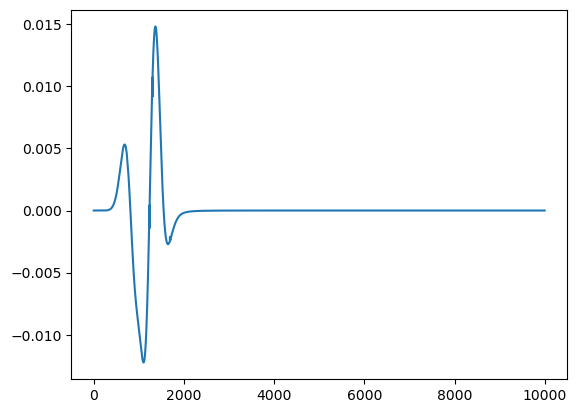

In [1314]:
plt.plot(vz_analytic[:, 1])

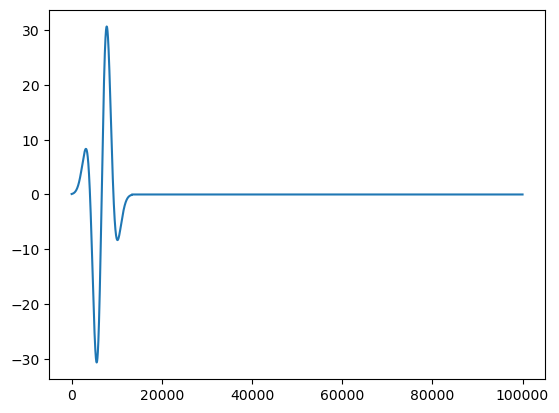

In [1315]:
plt.plot(source_analytic)

In [1316]:
with np.load('../devito_examples/homotilted/data_devito_homotilted.npz') as data:
    vx_devito = data['vx']
    vz_devito = data['vz']
    # vx_devito = data['v_xi']
    # vz_devito = data['v_eta']
    dt_devito = data['dt']

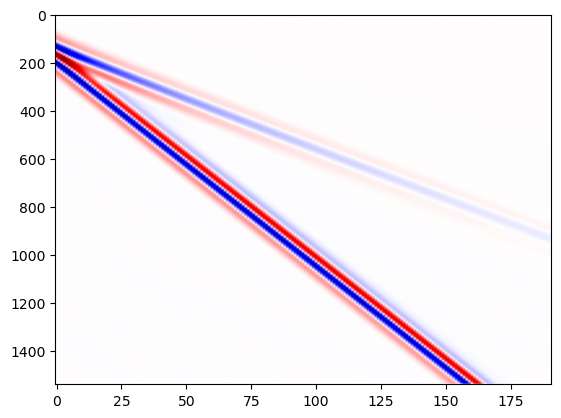

In [1317]:
plt.imshow(vx_devito, aspect='auto', cmap='seismic', vmin=-np.max(np.abs(vx_devito)), vmax=np.max(np.abs(vx_devito)))

In [1318]:
time_devito = np.arange(vx_devito.shape[0]) * dt_devito * 1e-3  # Convert ms to s
# Use time specfem as reference
# Interpolate Devito data to Specfem time grid using scipy interp
from scipy.interpolate import interp1d
time_shift = 0.0  # seconds
amplitude_scale_x = 1.95
amplitude_scale_z = 2.2
interp_vx = interp1d(time_devito+time_shift, vx_devito, axis=0, kind='cubic', bounds_error=False, fill_value=0.0)
interp_vz = interp1d(time_devito+time_shift, vz_devito, axis=0, kind='cubic', bounds_error=False, fill_value=0.0)
vx_devito_interp = interp_vx(time_analytic) * amplitude_scale_x 
vz_devito_interp = interp_vz(time_analytic) * amplitude_scale_z

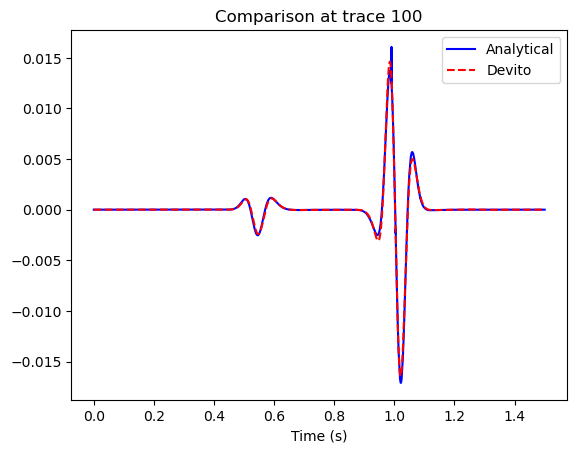

In [1319]:
trace_analytic = 1+10
trace_devito = 100
plt.plot(time_analytic, vx_analytic[:, trace_analytic], label='Analytical', color='blue')
plt.plot(time_analytic, vx_devito_interp[:, trace_devito], label='Devito', color='red', linestyle='--')
#plt.plot(time_analytic, vx_devito_interp[:, trace_devito] - vx_analytic[:, trace_analytic], label='Difference', color='black', linestyle='-')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace_devito}')
plt.legend()
plt.show()

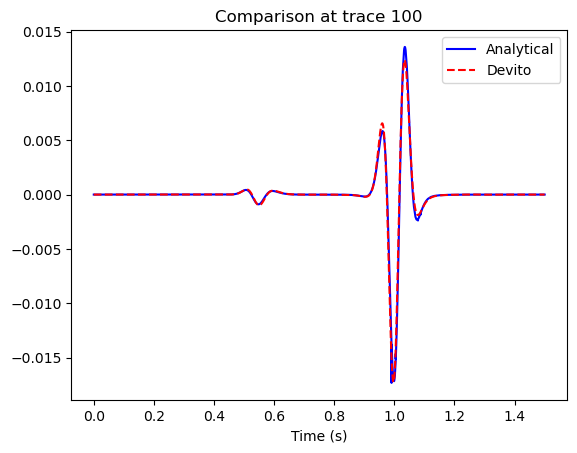

In [1320]:
plt.plot(time_analytic, vz_analytic[:, trace_analytic], label='Analytical', color='blue')
plt.plot(time_analytic, vz_devito_interp[:, trace_devito], label='Devito', color='red', linestyle='--')
#plt.plot(time_analytic, vz_devito_interp[:, trace_devito] - vz_analytic[:, trace_analytic], label='Difference', color='black', linestyle='-')
plt.xlabel('Time (s)')
plt.title(f'Comparison at trace {trace_devito}')
plt.legend()
plt.show()

In [1321]:
# # L2 error in trace 100
# trace = 100
# l2_error_vx_trace100 = np.linalg.norm(vx_devito_interp[:, trace] - vx_specfem[:, trace]) / np.linalg.norm(vx_specfem[:, trace]) 
# l2_error_vz_trace100 = np.linalg.norm(vz_devito_interp[:, trace] - vz_specfem[:, trace]) / np.linalg.norm(vz_specfem[:, trace])           
# print(f'Relative L2 error vx at trace {trace}: {l2_error_vx_trace100:.2%}')
# print(f'Relative L2 error vz at trace {trace}: {l2_error_vz_trace100:.2%}')

In [1322]:
# l2_error_vx_trace100

In [1323]:
# # L2 error per trace
# l2_errors_vx = np.linalg.norm(vx_devito_interp - vx_specfem, axis=0) / np.linalg.norm(vx_specfem, axis=0)
# l2_errors_vz = np.linalg.norm(vz_devito_interp - vz_specfem, axis=0) / np.linalg.norm(vz_specfem, axis=0)           
# plt.plot(l2_errors_vx[3:], label='$v_x$ error', color='green')
# plt.plot(l2_errors_vz[3:], label='$v_z$ error', color='orange')
# plt.xlabel('Trace number')
# plt.ylabel('Relative L2 error')
# plt.title('Relative L2 error per trace')
# plt.legend()